# This is a Simple Large Language Model

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

In [14]:
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)

print(device)

mps


# DATASET & CHARACTER TOKENIZATION

In [23]:
class Dataset():
    def __init__(self, data):
        self.data = data
        self.chars = sorted(list(set(self.data)))
        self.stoi = { ch:i for i,ch in enumerate(self.chars) }
        self.itos = { i:ch for i,ch in enumerate(self.chars) }

    def get_vocab_size(self):
        return len(self.chars)

    def get_chars(self):
        return self.chars

    def encode(self, text):
        return [self.stoi[c] for c in text]

    def decode(self, indices):
        return ''.join([self.itos[i] for i in indices])

    def split_data(self, train_ratio=0.9):
        data = torch.tensor(self.encode(self.data), dtype=torch.long)
        n = int(0.9 * len(data)) 
        train_data = data[:n]
        val_data = data[n:]
        return train_data, val_data

    def get_batch(self, split, batch_size, block_size):

        train_data, val_data = self.split_data()

        data_set = train_data if split == 'train' else val_data

        # Keep the input and target windows the same length, even for short datasets.
        if len(data_set) < block_size + 1:
            pad_len = (block_size + 1) - len(data_set)
            data_set = torch.cat([data_set, torch.zeros(pad_len, dtype=data_set.dtype)])

        max_idx = max(1, len(data_set) - block_size)
        if max_idx <= 1:
            ix = torch.zeros((batch_size,), dtype=torch.long)
        else:
            ix = torch.randint(0, max_idx, (batch_size,))

        x = torch.stack([data_set[i:i + block_size] for i in ix])
        y = torch.stack([data_set[i + 1:i + block_size + 1] for i in ix])
        return x, y

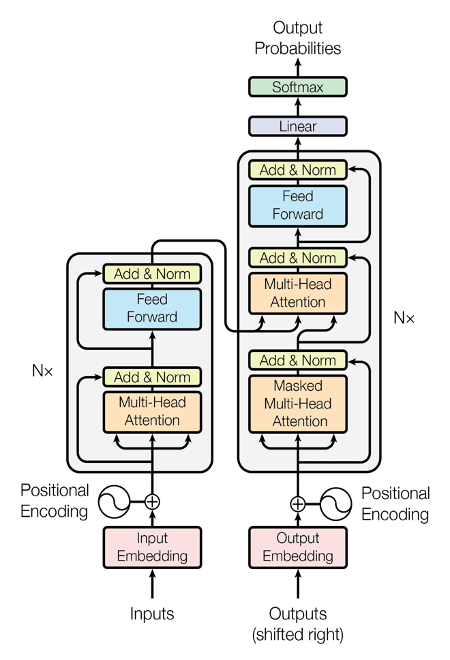

# Head Class (Self Attention)

### calculating 

$$Q = X W_Q, K = X W_K, V = X W_V$$

$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
 $$

In [24]:
class Head(nn.Module):
    def __init__(self, head_size, n_embd, block_size, dropout):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        """
         B (Batch Size): The number of independent samples processed at the same time (e.g., 32 sentences).
         T (Time / Sequence Length): The length of the sequence (e.g., a sentence with 10 words).
         C (Channels / Embedding Dimension): The number of features per step (e.g., a word vector of size 768, or 3 color channels for RGB).
        """
        B, T, C = x.shape

        k = self.key(x) 
        q = self.query(x)
        
        # Attention Scores
        # Compute the attention scores by taking the dot product of queries and keys, scaled by the square root of the embedding dimension.
        wei = q @ k.transpose(-2, -1) * (C**-0.5) 

        # Apply a mask to ensure that each position can only attend to previous positions (causal attention). 
        # This is done by setting the upper triangular part of the attention scores matrix to negative infinity,
        #  which will result in zero probabilities after applying softmax.
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) 
        wei = F.softmax(wei, dim=-1) 
        wei = self.dropout(wei)
        
        # Perform the weighted aggregation of values
        v = self.value(x) # (B, T, head_size)
        out = wei @ v     # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
        return out

# Multi Head Attention

$$ \text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O $$

In [25]:
class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention running in parallel """
    def __init__(self, num_heads, head_size, n_embd, block_size, dropout):
        super().__init__()

        self.heads = nn.ModuleList([Head(head_size, n_embd, block_size, dropout) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out)) 
        return out

# Feedforward Network

In [26]:
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

# Attention Block 

In [27]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size, n_embd, block_size, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ffwd = FeedForward(n_embd, dropout)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# My GPT Model 

In [28]:
class SimpleGPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()

        # Here is the embedding layer for tokens and positions.
        # The token embedding layer maps each token in the vocabulary to a vector of size n_embd
        # The position embedding layer maps each position in the input sequence to a vector of size n_embd.
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # Here are blocks of transformer layers. Each block consists of multi-head self-attention and feedforward layers.
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])

        # Final Norm Layer and Linear layer to project the output to the vocabulary size for prediction.
        self.ln_f = nn.LayerNorm(n_embd) 
        self.lm_head = nn.Linear(n_embd, vocab_size)

        self.block_size = block_size

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx) 
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) 

        x = tok_emb + pos_emb 

        x = self.blocks(x) 
        x = self.ln_f(x) 
        logits = self.lm_head(x) 

        # Compute the loss if targets are provided. The loss is computed using cross-entropy between the predicted logits and the true targets.
        if targets is None:
            loss = None
        else:
            logits = logits.reshape(-1, logits.size(-1))
            targets = targets.reshape(-1)

            if targets.numel() != logits.shape[0]:
                min_len = min(targets.numel(), logits.shape[0])
                logits = logits[:min_len]
                targets = targets[:min_len]

            loss = F.cross_entropy(logits, targets)

        return logits, loss

    """
    Generates new tokens given a starting sequence of indices (idx) and the maximum number of new tokens to generate (max_new_tokens).
    The method iteratively predicts the next token based on the current sequence, appends it to the sequence, 
    and continues until the desired number of new tokens is generated.
    """

    def generate(self, idx, max_new_tokens):

        for _ in range(max_new_tokens):
            # Crop context if it exceeds our fixed block size limit
            idx_cond = idx[:, -self.block_size:]
            logits, loss = self(idx_cond)

            logits = logits[:, -1, :]  # Becomes (B, C)
            probs = F.softmax(logits, dim=-1)  # (B, C)

            # Sample next token from the output probability distribution
            idx_next = torch.multinomial(probs, num_samples=1)

            # Append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1)  # (B, T+1)

        return idx

# Train My GPT

In [29]:
text = """
To be, or not to be, that is the question:
Whether 'tis noble in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die—to sleep
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to: 'tis a consummation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's the rub:
For in that sleep of death what dreams may come,
When we have shuffled off this mortal coil,
Must give us pause.
"""

max_iters = 1500
eval_interval = 300 
eval_iters = 100

dataset = Dataset(text)

model = SimpleGPT(vocab_size=dataset.get_vocab_size(), n_embd=64, n_head=4, n_layer=4, block_size=64, dropout=0.1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = dataset.get_batch(split, batch_size=32, block_size=64)
            X = X.to(device)
            Y = Y.to(device)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

print("Starting training...")
for iter in range(max_iters):

    # Periodic verification of training progress
    if iter % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # Sample a batch of data
    xb, yb = dataset.get_batch('train', batch_size=32, block_size=64)
    xb = xb.to(device)
    yb = yb.to(device)

    # Evaluate the loss and update gradients
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

losses = estimate_loss()

Starting training...
step 0: train loss 3.8866, val loss 3.8817
step 300: train loss 0.2816, val loss 6.2468
step 600: train loss 0.0776, val loss 7.9513
step 900: train loss 0.0616, val loss 8.6347
step 1200: train loss 0.0556, val loss 9.2102


In [30]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_tokens = model.generate(context, max_new_tokens=300)[0].tolist()
print(dataset.decode(generated_tokens))


To die—to sleep
No more; and by a sleep to say we end
The heart-ache and the thousand natural shocks
That is he heir to: 'tis a consuat summmation
Devoutly to be wish'd. To die, to sleep;
To sleep, perchance to dream—ay, there's we the rub:
For in that sleep of death what dreams may come,
Whenp when
